In [98]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

np.random.seed(42)

In [78]:
# ── Load dataset ──────────────────────────────────────────────────────────────
df = pd.read_csv('Egypt_Houses_Price.csv', encoding='latin1')
print("Shape:", df.shape)
print(df.head())

Shape: (27361, 12)
     ï»¿Type    Price Bedrooms Bathrooms Area Furnished   Level Compound  \
0     Duplex  4000000        3         3  400        No       7  Unknown   
1  Apartment  4000000        3         3  160        No     10+  Unknown   
2  Apartment  2250000        3         2  165        No       1  Unknown   
3  Apartment  1900000        3         2  230        No      10  Unknown   
4  Apartment  5800000        2         3  160        No  Ground  Eastown   

  Payment_Option  Delivery_Date  Delivery_Term                    City  
0           Cash  Ready to move       Finished               Nasr City  
1           Cash  Ready to move       Finished             Camp Caesar  
2           Cash  Ready to move       Finished                   Smoha  
3           Cash  Ready to move       Finished               Nasr City  
4           Cash  Ready to move  Semi Finished  New Cairo - El Tagamoa  


ï»¿Type             0
Price               2
Bedrooms          203
Bathrooms         171
Area              471
Furnished           0
Level               0
Compound            0
Payment_Option      0
Delivery_Date       0
Delivery_Term       0
City                0
dtype: int64


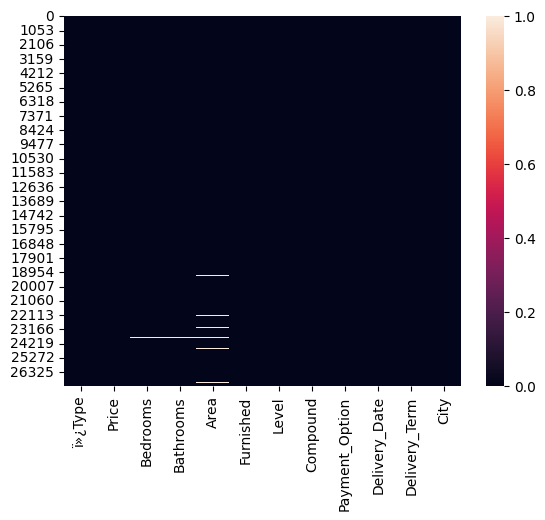

In [79]:
# ── Missing values ────────────────────────────────────────────────────────────
print(df.isnull().sum())
sns.heatmap(df.isnull(), cbar=True)
plt.show()

ï»¿Type             0
Price               2
Bedrooms          203
Bathrooms         171
Area              471
Furnished           0
Level               0
Compound            0
Payment_Option      0
Delivery_Date       0
Delivery_Term       0
City                0
dtype: int64


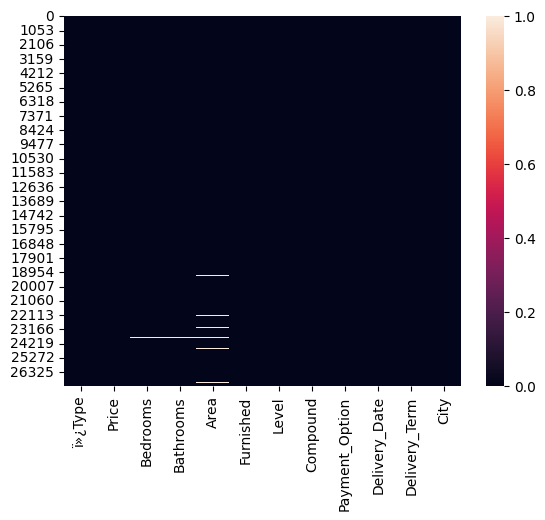

In [61]:
# Missing values
print(df.isnull().sum())

sns.heatmap(df.isnull(), cbar=True)
plt.show()

In [80]:
# ── Clean Price ───────────────────────────────────────────────────────────────
def clean_price(x):
    if pd.isna(x) or x == 'Unknown':
        return np.nan
    try:
        return float(x)
    except:
        return np.nan

df['Price'] = df['Price'].apply(clean_price)
df = df.dropna(subset=['Price'])

In [81]:
def clean_numeric(x):
    if pd.isna(x) or x == 'Unknown':
        return np.nan
    try:
        return float(str(x).replace('+', ''))
    except:
        return np.nan

for col in ['Bedrooms', 'Bathrooms', 'Area']:
    df[col] = df[col].apply(clean_numeric)
    df[col].fillna(df[col].median(), inplace=True)

In [82]:
# ── Clean categorical columns ─────────────────────────────────────────────────
def clean_cat(x):
    if pd.isna(x) or x == 'Unknown':
        return 'Unknown'
    return str(x).strip()

for col in ['ï»¿Type', 'Furnished', 'Level', 'Payment_Option', 'Delivery_Term', 'City']:
    df[col] = df[col].apply(clean_cat)

In [83]:
# ── Feature Engineering ───────────────────────────────────────────────────────
df['Total_Rooms']   = df['Bedrooms'] + df['Bathrooms']
df['Price_per_Area'] = df['Price'] / df['Area']
df['Area_per_Room'] = df['Area'] / df['Total_Rooms']

In [84]:
# ── Train / Test Split (BEFORE encoding to avoid data leakage) ────────────────
X = df.drop('Price', axis=1)
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=101
)

In [85]:
# ── Encode categorical columns (fit on train only) ────────────────────────────
label_encoders = {}
categorical_cols = X_train.select_dtypes(include=['object']).columns

for col in categorical_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    # Handle unseen labels in test set gracefully
    X_test[col] = X_test[col].map(
        lambda x, le=le: le.transform([x])[0] if x in le.classes_ else -1
    )
    label_encoders[col] = le

print(X_train.dtypes)

ï»¿Type             int64
Bedrooms          float64
Bathrooms         float64
Area              float64
Furnished           int64
Level               int64
Compound            int64
Payment_Option      int64
Delivery_Date       int64
Delivery_Term       int64
City                int64
Total_Rooms       float64
Price_per_Area    float64
Area_per_Room     float64
dtype: object


In [86]:
# ── Scaling ───────────────────────────────────────────────────────────────────
feature_names = X_train.columns.tolist()

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

In [87]:
# ── Train base model ──────────────────────────────────────────────────────────
model = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=6)
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [88]:
# ── Evaluate base model ───────────────────────────────────────────────────────
y_pred = model.predict(X_test)
print("R2  :", r2_score(y_test, y_pred))
print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2  : 0.8788774125402401
MAE : 200692.97707025532
RMSE: 2418268.954311692
